# Harris Corner Detection

In [3]:
import numpy as np
import matplotlib.pyplot as plt
import cv2
%matplotlib inline

## Harris Corner Detection: Steps

1. **Compute Image Gradients** $(I_x, I_y)$
   - Central differences in $x$ and $y$. `cv2.filter2D` is used for the convolution; everything else is implemented from scratch for better understanding.

2. **Compute Window Sums** (Structure Tensor $M$)
   - For each pixel, sum $I_x^2$, $I_y^2$ and $I_x I_y$ over a small window around it.
   - These sums form $M = \begin{bmatrix} S_{xx} & S_{xy} \\ S_{xy} & S_{yy} \end{bmatrix}$, which describes how intensity changes in that neighborhood.

3. **Compute Harris Response**
   - $R = \det(M) - k\,\text{trace}(M)^2$, which avoids computing eigenvalues directly.
   - $R$ is large and positive at corners, negative along edges, and $\approx 0$ in flat regions.
   - Scaled so the strongest corner has $R = 1$.

4. **Thresholding and Non-Max Suppression**
   - **Threshold:** keep only pixels with $R \geq$ `thresh` (a fraction of the max response).
   - **Suppress close peaks:** keep a pixel only if it is the maximum in its neighborhood, so one real corner doesn't produce a blob of detections.

5. **Get Corner Locations and Draw**
   - Collect the $(row, col)$ coordinates of the remaining pixels and draw each as a small circle on the original image.
  
To better understand the math behind these steps: https://www.cs.cornell.edu/courses/cs4670/2013fa/lectures/lec06_harris.pdf

### Read Image

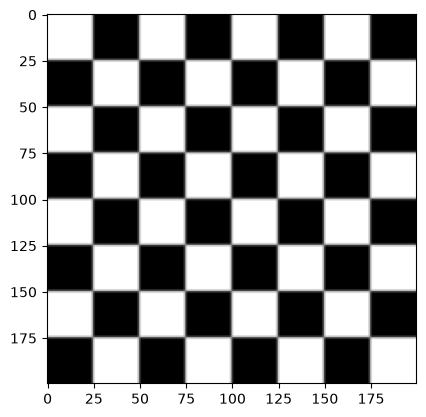

In [4]:
from skimage import data
image = data.checkerboard()
plt.imshow(image, cmap = 'gray')

## Step 1: Image Gradients

Corners are points where intensity changes in **two** directions. We measure change with the gradients $I_x$ and $I_y$, computed by central differences:

$$I_x = I(x+1, y) - I(x-1, y), \qquad I_y = I(x, y+1) - I(x, y-1)$$

In [17]:
def compute_gradients(img):
    """
    Compute x and y image gradients using central differences.
    """
    img = img.astype(np.float32)
    k_x = np.array([[-1, 0, 1]], dtype=np.float32)      # I(x+1) - I(x-1)
    Ix = cv2.Sobel(img, cv2.CV_32F, 1, 0, ksize=3)     # d/dx
    Iy = cv2.Sobel(img, cv2.CV_32F, 0, 1, ksize=3)     # d/dy                  # same kernel, vertical
    return Ix, Iy

## Step 2: Structure Tensor (Window Sums)

For each pixel, gradient products are summed over a small window $W$ around it:

$$M = \begin{bmatrix} \sum I_x^2 & \sum I_x I_y \\ \sum I_x I_y & \sum I_y^2 \end{bmatrix} = \begin{bmatrix} S_{xx} & S_{xy} \\ S_{xy} & S_{yy} \end{bmatrix}$$

$M$ summarizes how intensity changes in that neighborhood. The sums are computed for all pixels at once by filtering each product with a window of ones.

In [7]:
def compute_window_sums(Ix, Iy, window_size=3):
    """
    Sum gradient products over a window around each pixel (the entries of M).
    """
    window = np.ones((window_size, window_size), dtype=np.float32)

    # each output pixel = sum of the product over the window centered on it
    # loop equivalent: Sxx[i, j] = np.sum((Ix * Ix)[i-rad:i+rad+1, j-rad:j+rad+1])
    Sxx = cv2.filter2D(Ix * Ix, -1, window)
    Syy = cv2.filter2D(Iy * Iy, -1, window)
    Sxy = cv2.filter2D(Ix * Iy, -1, window)
    return Sxx, Syy, Sxy

## Step 3: Harris Response

The eigenvalues $\lambda_1, \lambda_2$ of $M$ describe the neighborhood:

| $\lambda_1, \lambda_2$ | Region |
|---|---|
| both small | flat |
| one large, one small | edge |
| both large | **corner** |

Instead of computing eigenvalues, Harris uses the equivalent score:

$$R = \det(M) - k\,\text{trace}(M)^2 = \lambda_1\lambda_2 - k(\lambda_1 + \lambda_2)^2$$

with $k \approx 0.04$–$0.06$. $R$ is large and positive at corners, negative along edges, and near zero in flat regions. It is scaled so the strongest corner has $R = 1$.

In [8]:
def compute_harris_response(Sxx, Syy, Sxy, k=0.04):
    """
    Compute R = det(M) - k * trace(M)^2 at every pixel, scaled so the max is 1.
    """
    
    det = Sxx * Syy - Sxy ** 2          
    trace = Sxx + Syy                   
    R = det - k * trace ** 2
    return R / R.max()      

## Step 4: Thresholding and Non-Max Suppression

A single corner produces a small blob of high $R$ values. To get one point per corner:

1. **Threshold:** keep pixels with $R \geq$ `thresh` (a fraction of the strongest response).
2. **Non-max suppression:** keep a pixel only if it is the maximum in its `nms_size × nms_size` neighborhood.

In [9]:
def nonmax_suppression(R, thresh, window_size=3):
    """
    Keep pixels above thresh that are the maximum in their neighborhood.
    """
    H, W = R.shape
    rad = window_size // 2
    corners = np.zeros((H, W), dtype=bool)

    for i, j in np.argwhere(R >= thresh):                 # only check strong candidates
        if rad <= i < H - rad and rad <= j < W - rad:     # skip image borders
            nbs = R[i-rad:i+rad+1, j-rad:j+rad+1]
            corners[i, j] = R[i, j] == nbs.max()           # local max -> corner

    return corners

## Step 5: Corner Locations and Drawing

The $(row, col)$ coordinates of the remaining pixels are the detected corners. Each is drawn as a small circle on the original image. OpenCV expects points as $(x, y) = (col, row)$.

In [14]:
def get_corner_locations(corners):
    """
    Return (row, col) coordinates of all corner pixels.
    """
    return np.argwhere(corners)


def draw_corners(img, corner_locs, color=(255, 0, 0), radius=2):
    """
    Draw each corner as a filled circle on an RGB copy of the image.
    """
    out = cv2.cvtColor(img, cv2.COLOR_GRAY2RGB) if img.ndim == 2 else img.copy()
    for r, c in corner_locs:
        cv2.circle(out, (int(c), int(r)), radius, color, -1)   # cv2 expects (x, y) = (col, row)
    return out

In [11]:
def detect_harris_corners(img, window_size=3, k=0.04, thresh=0.01, nms_size=3):
    """
    Run the full Harris pipeline; return intermediate results for plotting.
    """
    Ix, Iy = compute_gradients(img)
    Sxx, Syy, Sxy = compute_window_sums(Ix, Iy, window_size)
    R = compute_harris_response(Sxx, Syy, Sxy, k)
    corners = nonmax_suppression(R, thresh, nms_size)
    corner_locs = get_corner_locations(corners)
    out = draw_corners(img, corner_locs)
    return Ix, Iy, R, corners, out

detected 196 corners


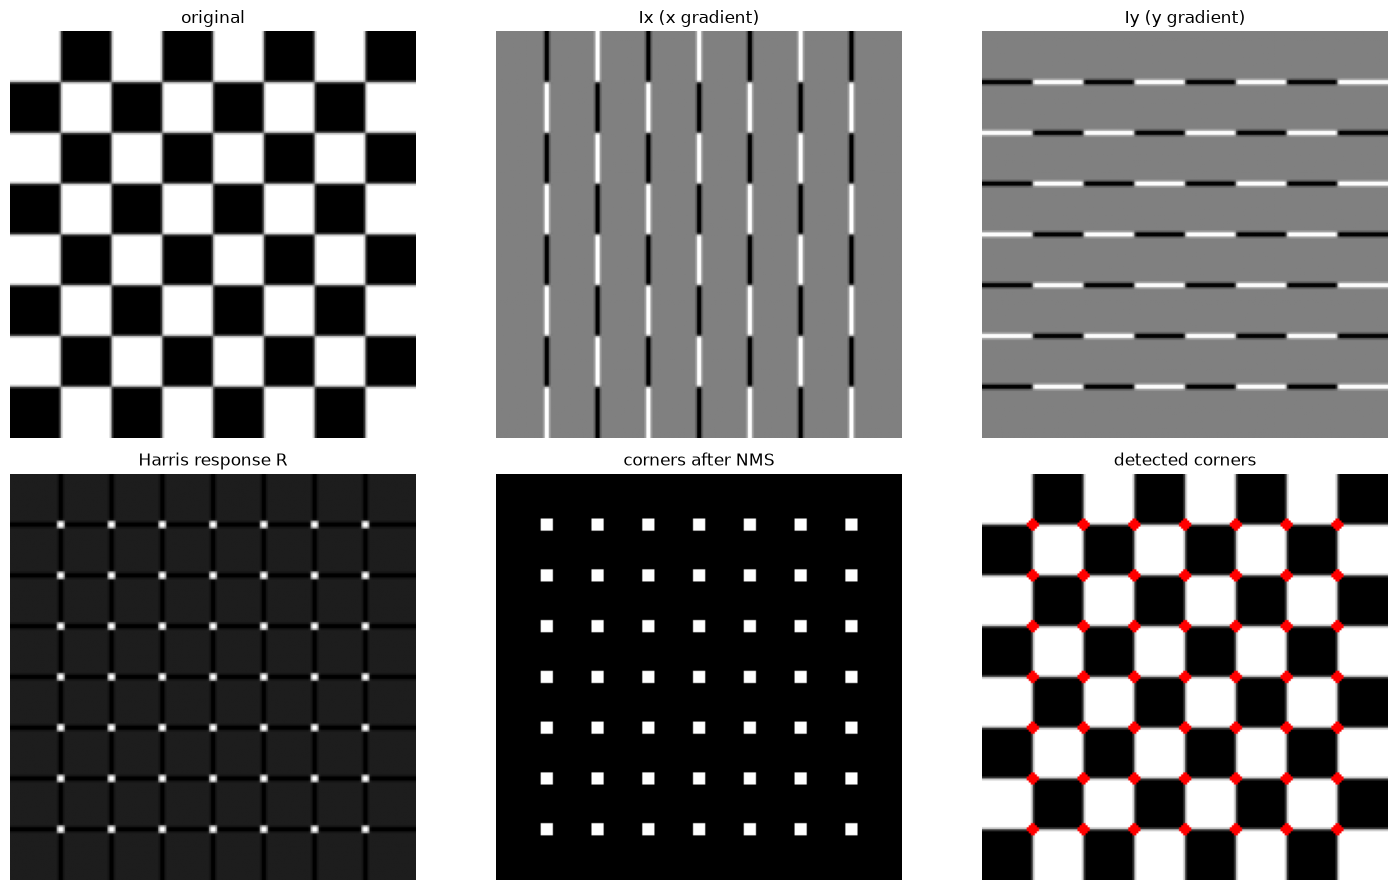

In [16]:
Ix, Iy, R, corners, out = detect_harris_corners(image, window_size=3, k=0.04, thresh=0.01, nms_size=3)
print(f"detected {corners.sum()} corners")

# corners are single pixels; dilate them so they're visible when plotted
corners_vis = cv2.dilate(corners.astype(np.uint8), np.ones((5, 5), np.uint8))

fig, axes = plt.subplots(2, 3, figsize=(15, 9))

panels = [
    (image,         'original',              'gray'),
    (Ix,          'Ix (x gradient)',       'gray'),   # diverging: sign matters
    (Iy,          'Iy (y gradient)',       'gray'),
    (R,           'Harris response R',     'gray'),
    (corners_vis, 'corners after NMS',     'gray'),
    (out,         'detected corners',      None),     # already RGB
]

for ax, (im, title, cmap) in zip(axes.ravel(), panels):
    ax.imshow(im, cmap=cmap)
    ax.set_title(title)
    ax.axis('off')

plt.tight_layout()
plt.show()